## MaMa course practical


## Introduction

Marine heatwaves are becoming more frequent, intense, and persistent as a consequence of climate change, with significant implications for coastal systems. Although seawater temperature is commonly used to characterize thermal exposure, benthic organisms are directly influenced by thermal dynamics of the sediment.

Sediments act as a thermal reservoir, where heat transfer is governed by conduction, sediment properties and hydrodynamic conditions. Consequently, thermal signals can be attenuated, delayed, or amplified within the sediment profile, potenttially prolonging exposure to stressful temperatures, even after water temperatures have declined. 

![intertidal_gradient](images/intertidal_gradient_sediment_vertical_distribution.png)

Hence, we aim to explore how sediment temperature varies across space and time in the intertidal zone of the Dutch Wadden Sea. In this document, you will be tasked with analyzing high frequency datasets you derived from your field work and develop a conceptual and simple model of the sediment heat budget over tidal cycle, sediment type(s) and/or inundation gradient.

## TempSED - Sediment temperature model

This document contains snippet of code to get you started in modeling sediment temperature using the TempSED. Basically, the model aim to simulate the temperature of the bulk sediment as a function of depth and time. For the mathematically inclined ones, are essencially solving the following partial differential equation. But don't worry! You will not solve the equation analytically. We will let computer do the work for us.

$$\frac{\partial T_{bs}}{\partial t} = \frac{1}{c_{bs} \cdot \rho_{bs}} \cdot \frac{\partial }{\partial x}(K_{bs} \cdot \frac{\partial T_{bs}}{\partial x}) - \frac{1}{c_{bs} \cdot \rho_{bs}} \cdot \frac{\partial I}{\partial x}$$


where $x$ and $t$ denote depth in the sediment and time, respectively. In this equation, the first term on the right-hand side represents the heat flow due to temperature gradients, while the second term represents the heat source due to attenuation of the incident short-wave solar radiation (I , in W m−2) in the sediment. Furthermore, the parameters $k_{bs}$  $c_{bs}$ and $\rho_{bs}$ denote the thermal conductivity (W m−1 K−1), specific heat capacity (J kg−1 K−1) and density (kg m−3) of the bulk sediment, respectively. Because bulk sediment is a mixture of different types of solids and water, these parameters depend on the sediment porosity and thus, in general, vary with depth in the sediment.

with boundary conditions

$$\frac{\partial T_{bs}}{\partial x}|_{x=\infty} = 0,$$ at the lower boundary, and $$K _{bs} \cdot \frac{\partial T_{bs}}{\partial x}|_{x=0} =  H_0,$$ at the upper boundary, when exposed to the air, or $$T_{bs}|_{x=0}=T_{ow},$$ When exposed to the water.

Suffice to say, we will use a computer program developed at NIOZ to simulate how sediment temperature will response to varying atmospheric and water condition. To do that, first you need to install R and some external packages (In the lab, I can help you if you run into installation issues). Ideally, if would install an integrated development environment (IDE) called R-studio but you can do without it. Next, run the following code below to install `TempSED`:\



In [1]:
# library(TempSED)
devtools::load_all("../TempSED/")
devtools::load_all("~/../../home/lter_life_dev/git_repos/dtR/dtRtools/")
devtools::load_all("~/../../home/lter_life_dev/git_repos/dtR/dtRwad/")
source("scripts/helper_function.R")

ℹ Loading TempSED
Loading required package: deSolve
Loading required package: rootSolve
Loading required package: plot3D
ℹ Loading dtRtools
Loading required package: sf
Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE
ℹ Loading dtRwad



With the package installed, Function *TempSED_run1D* implements the one-dimensional mechanistic model for sediment temperature in the vertical dimension. It is a numerical model, where the sediment is subdivided in 100 vertical boxes. The model units are $m$, $s$, $^oC$. See appendix for the model equations.

The function is defined as:


In [2]:
Def_fun <- function(name){
  Z <- paste(as.character(deparse(name)), collapse="\n")
  Z <- substr(Z, 1, regexpr("{",Z,fixed =TRUE)-1)
  for (i in 1:10)
    Z <- gsub("  ", " ", Z)
  cat(paste(substitute(name),substr(Z, 9, nchar(Z))),"\n")
}
Def_fun(TempSED_run1D)

TempSED_run1D  (parms = list(), times = 1:3600, T_ini = 10, z_max = 10, 
 dz_1 = 0.001, Grid = setup.grid.1D(N = 100, dx.1 = dz_1, 
 L = z_max), porosity = 0.5, irrigation = 0, f_Waterheight = 0, 
 f_Watertemperature = 10, f_Airtemperature = 10, f_Qrel = 0.3, 
 f_Pressure = 101325, f_Solarradiation = 100, f_Windspeed = 1, 
 f_Cloudiness = 0.5, f_Deeptemperature = NA, dependency_on_T = FALSE, 
 sedpos = NULL, verbose = FALSE, dtmax = 3600) 
 



where

- *z_max*, *dz\_.\_1* are the total sediment depth and the size of the first box, in $m$,
- *porosity* is the sediment porosity,
- *T_ini* is the initial condition; times represents the output times for the model,
- *f_Waterheight*, *f_Watertemperature*, the overlying water conditions
- *f_Airtemperature*, *f_Qrel*, *f_Pressure*, *f_Solarradiation*, *f_Windspeed*, *f_Cloudiness* are the atmospheric conditions,
- *irrigation* is the sediment irrigation rate,
- *sedpos*, if not NULL, is a vector with sediment depths whose temperature needs to be outputted.

The forcings are either a time series, a function that takes an argument time, or one value.

the following parameters can be defined in *parms*:

- *cp_water*, *cp_solid* in $J/kg/K$, *tc_water*, *tc_solid* in $W/m/K$ and *density_water*, *density_solid* in $kg/m3$, is the specific heat capacity (cp..), the thermal conductivity (tc..), and the density (dens..) for water and the solid fraction respectively.
- *albedo_water*, *albedo_sediment*, *kd_water*, *kd_sediment* are the albedo (reflectance, $-$) and light extinction coefficient ($/m$) for water and sediment respectively,
- *em_air*, *em_sediment*, are the emissivity of air and bulk sediment respectively,

Arguments *porosity*, *irrigation* and *T_ini* can either be one value or a function that takes as an argument the sediment depth. *T_ini* can also be the output of a previous run, if the model needs to be restarted.

### Your first simple model

For this simple model, we will simulate the sediment temperature up to maximum depth of 10m, with thickness of 0.04 cm (i.e 0.0004 m). For simplicity, we will imposed a constant porosity of 0.9 but this can be changed to described how porosity will change with depth. We will assumed the initial air temperature is 15 degree and a solar radiation at high afternoon of 270 W/m2. We will run for the period of MaMa course (2 weeks).


In [2]:

z_max    <- 10
dz_1     <- 1e-4
length.z <- 10
porosity  <- 0.9
fAirTempYr <- 15 
fSolarRadYr <- 270
days_to_run <- 14 

times <- seq(from = 0, to = days_to_run*86400, by = 86400)

simple_model <-TempSED_run1D(
  z_max =z_max,
  dz_1 =dz_1,
  porosity =porosity,
  times =times,
  T_ini =10,
  f_Airtemperature=fAirTempYr,
  f_Solarradiation=fSolarRadYr)



Now we can visualize our result:

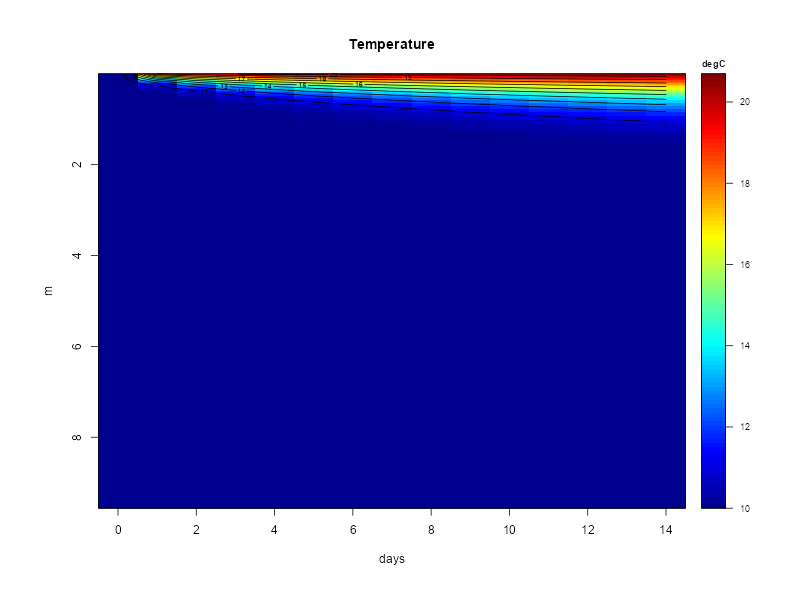

Warning message:
In rep(dots, length.out = n) : 'x' is NULL so the result will be NULL


In [4]:
T_air<-subset(simple_model,which="Airtemperature")
image2D(simple_model, main = "Temperature", xlab = "days",
        clab = "degC", ylab = "m", time_unit = "day",
        contour = TRUE, mfrow = NULL)


### Constructing a realistic sediment temperature model

Simple like that! Hopefully this can give you an impression on how the model works. Now, you will build upon this to construct a realistic model driven by the data you obtained from the field.

For that, we need data to `Force` the model, `boundary conditions` to enforce exchange on energy and heat between the sediment and its overlying media and `observed data` to calibrate/validate the model.

Speaking of observed data, we can first take a look at the task at hand. What kind of profile are we to expect here. With one of your field data, we can read it and visualize the sediment temperature.

Note, here the name of the data are in the same form as was given to me by Tjitske (your other supervisor). Although she provided a well-documented metadata table to associate each unique dataset for their extensive field campaign with the individual logger, for you data, you need to label and name things well. All I am saying is proper data management is key to effective data analysis.  

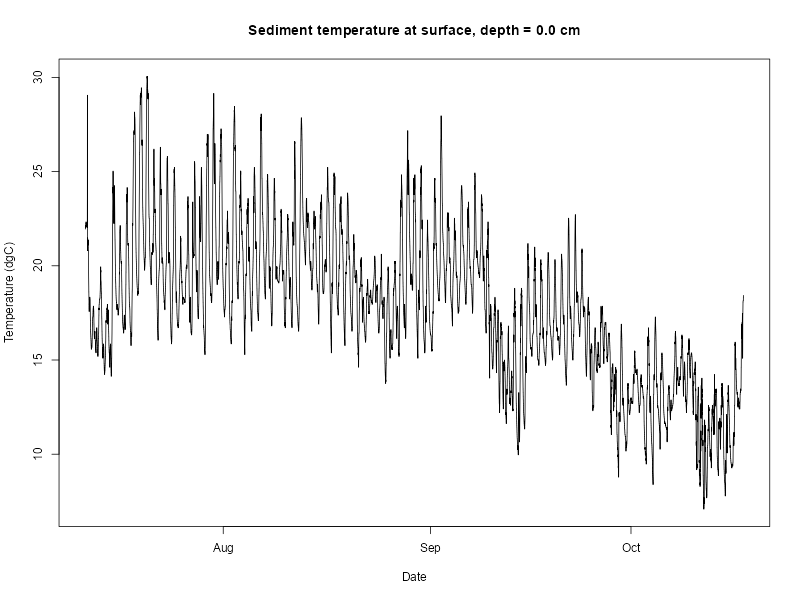

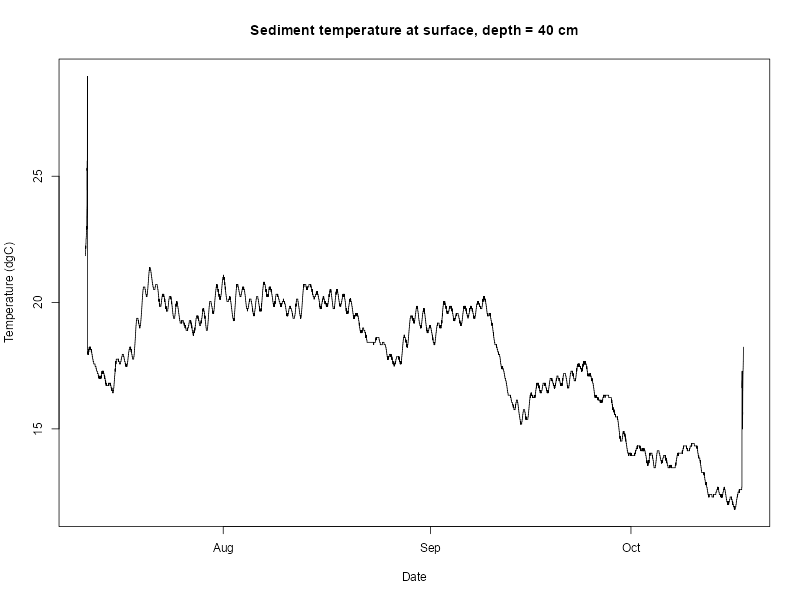

In [3]:
## Surface 
data_21923817 <- read.csv("datasets/21923817.csv", skip = 1)

data_21923817 <- data_21923817[, 2:3]
names(data_21923817) <- c("date", "temperature")
data_21923817$date <- as.POSIXct(data_21923817$date, format = "%m/%d/%Y %I:%M:%S %p", tz = "GMT")
head(data_21923817)

with(data_21923817, plot(date, temperature, type = "l", 
    main = "Sediment temperature at surface, depth = 0.0 cm", 
    ylab = "Temperature (dgC)", xlab = "Date"))

## Deep 
data_22026091 <- read.csv("datasets/22026091.csv", skip = 1)

data_22026091 <- data_22026091[, 2:3]
names(data_22026091) <- c("date", "temperature")
data_22026091$date <- as.POSIXct(data_22026091$date, format = "%m/%d/%Y %I:%M:%S %p", tz = "GMT")
head(data_22026091)

with(data_22026091, plot(date, temperature, type = "l",
    main = "Sediment temperature at surface, depth = 40 cm", 
    ylab = "Temperature (dgC)", xlab = "Date"))

### Atmospheric forcing

Beyond the observed data, our model need some atmospheric data that drive changes we observed in the sediment. Important meteorological data are crucial to properly simulate how the sediment will response at different timescale. For example, on a warm day, we expect higher air temperature and high solar radiation which *can* propagate heat to the sediment, however, things are not so simple as you would as other factors like windspeed, atmospheric pressure, sky albedo (cloudiness) can affect how much heat is exchanged on the mudflat. So, we need to take all this into account.

For that, you will need to get your hands on some meteorological data from KNMI. Head over to this website (KNMI) \[<https://daggegevens.knmi.nl/klimatologie/uurgegevens>\] and grab some data in one of the several stations closest to your sampling location.

![KNMI weather download](images/knmi_screenshot_1.png)

In [4]:
### Load your data here 
atmospheric_forcing <- read_KNMI(file = "KNMI_De_Kooy_2024.txt", dir = "datasets/")
atmospheric_forcing$time_cest <- as.POSIXct(format(atmospheric_forcing$datetime, tz = "CET", usetz = TRUE))

start_date <- sort(atmospheric_forcing$time_cest)[1]
atmospheric_forcing$second <- as.numeric(difftime(atmospheric_forcing$time_cest, start_date, units = "secs"))

atmospheric_forcing$pressure <- atmospheric_forcing$pressure * 100 # from Hpa to pa
atmospheric_forcing$cloudcover <- atmospheric_forcing$cloudcover/8 # from 0-8 to 0-1 
## Select station closer to Denhelder
Dekooy <- subset(atmospheric_forcing, which = station == 235) # De Kooy
Dekooy <- Dekooy[order(Dekooy$datetime) & !is.na(Dekooy$datetime), ]

fWind_wad       <- Dekooy[, c("second", "windspeed")]
fRad_wad        <- Dekooy[, c("second", "radiation")]
fTair_wad       <- Dekooy[, c("second", "temperature")]
fPair_wad       <- Dekooy[, c("second", "pressure")] 
fhumidity_wad   <- Dekooy[, c("second", "humidity")]
fCloud_wad      <- Dekooy[, c("second", "cloudcover")]

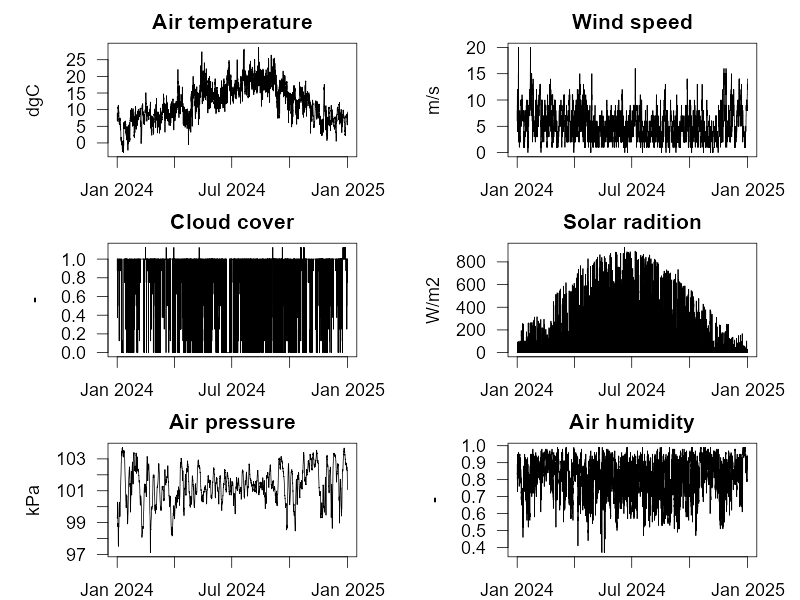

In [8]:
op <- par(mfrow = c(3, 2), mar = c(2, 5, 2, 2), las = 1, cex = 1.5)
plot(Dekooy$datetime, Dekooy$temperature, type = "l", ylab = "dgC", main = "Air temperature")
plot(Dekooy$datetime, Dekooy$windspeed, type = "l", ylab = "m/s", main = "Wind speed")
plot(Dekooy$datetime, Dekooy$cloudcover, type = "l", ylab = "-", main = "Cloud cover")
plot(Dekooy$datetime, Dekooy$radiation, type = "l", ylab = "W/m2", main = "Solar radition")
plot(Dekooy$datetime, Dekooy$pressure/1000, type = "l", ylab = "kPa", main = "Air pressure")
plot(Dekooy$datetime, Dekooy$humidity, type = "l", ylab = "-", main = "Air humidity")
par(op)


### Boundary and Initial conditions

In addition to the atmosphere, the sediment is mostly in contact with the water. However, this is phase dependent in the Wadden sea with strong tidal ebb and flow. Thus, the system (i.e sediment) is periodically exposed and submerged. Thus, properties of the overlying water changes with time (i.e water height, temperature and potentially salinity). This is crucially important as they modulate how much the sediment heats up.

To drive your model, you need an estimate of the water temperature and height at the site of collection. You can get some approximation of the water temperature and water height using measurement from Rijkwaterstraat sensors fixed at several locations in the Wadden Sea [https://waterinfo.rws.nl/].


### Historical data forcing 
For historical data as in this **demo**, we want to download dataset for 2024 when Tjitske and Oscar deployed their sensors. For that we can click on `Download historische data` in the expert panel. And proceed to select the date range of interest, and type of dataset we are interested in (water height and temperature).

![Landing page RWS](images/rws_screenshot_1.png)


Let's load this 2024 pre-downloaded data and plot the stations. Reading the full raw data contains a lot of stations and loading of the dataset takes time. So, I chunk and truncated the data into the stations that are relevant our work in this MaMa course. 

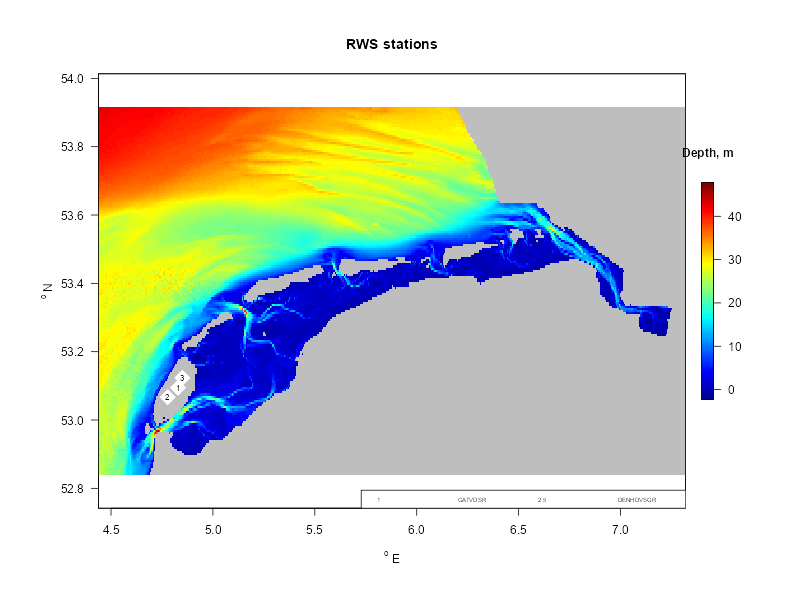

In [6]:
## Reading the full raw big data (~650 MB)
# RWS_parse <- read_RWS_recent_patch(dir = "../vl-tempsed-wadden-sea/datasets/", 
#                                    file = "20251024_009.csv", 
#                                    format = "long")

# RWS_parse <- read.csv("datasets/RWS_2024.csv")
load("datasets/RWS_2024.rda")

RWS_parse$value <- as.numeric(RWS_parse$value)

stats <- attributes(RWS_parse)$stations
plot_bathymetry(Wad_depth, 
               pts=stats[,c("longitude", "latitude")], 
               ptlist=list(cex=3, col= "white"), NAcol="grey", type="image",
               main="RWS stations", clab = "Depth, m")
text(stats$longitude, stats$latitude, labels=1:nrow(stats), cex=0.7)
nr <- nrow(stats)
legend("bottomright", legend=c(1:(nr/2), stats$station[1:(nr/2)], 
                              (nr/2+1):nr, stats$station[(nr/2+1):nr]), 
       ncol=4, cex=0.5)


# plot(meta(RWS_parse)$stations$longitude, meta(RWS_parse)$stations$latitude, type = "p", col = 1, pch = 19)
# text(meta(RWS_parse)$stations$longitude, meta(RWS_parse)$stations$latitude, label = meta(RWS_parse)$stations$station, cex = 0.5)

Moreso, we only need stations closest to where our temperature loggers are. So, we can subset the data and clean some things up and then prepare a **boundary condition** data for the water height and temperature.

In [7]:

water_forcing <- subset(RWS_parse, subset = station == "OUDSD")

## For this dataset, we can subset for only year = 2024
water_forcing <- subset(water_forcing, subset = datetime >= as.POSIXct("2024-01-01") & datetime <= as.POSIXct("2024-12-31"))

water_forcing$datetime_cest <- as.POSIXct(format(water_forcing$datetime, tz = "CET", usetz = TRUE))

water_forcing$second <- as.numeric(difftime(water_forcing$datetime_cest, start_date, units = "secs"))
# water_forcing$second <- as.double(julian(water_forcing$datetime, origin = start_date) * 86400)

fHwater <- subset(water_forcing, subset = variable == "Height")[, c("second", "value")]

fHwater <- fHwater[fHwater$second >= 0, ]
fHwater$value[fHwater$value < 0] <- 0


nearby_water_forcing <- subset(RWS_parse, subset = station == "GATVDSR")
# nearby_water_forcing <- subset(RWS_parse, subset = station == "DENHDVSGR" & variable == "T")

nearby_water_forcing$datetime_cest <- as.POSIXct(format(nearby_water_forcing$datetime, tz = "CET", usetz = TRUE))

nearby_water_forcing$second <- as.numeric(difftime(nearby_water_forcing$datetime_cest, start_date, units = "secs"))
fTwater <- subset(nearby_water_forcing, subset = variable == "T")[, c("second", "value")]

fTwater <- fTwater[!is.na(fTwater$second), ]

fTwater <- fTwater[fTwater$second >= 0, ]

## Water forcing seems off, so I interpolate it to the observed air tempoerature time stamp
fTwater_int <- as.data.frame(approx(x = fTwater$second, y = fTwater$value, xout = fTair_wad$second, rule = 2))


Now, we have all the necessary data or forcings needed to drive our model. Before, we do so, what can this workflow be adapted your situation. Surely you don't need 2024 data set for 2026 MaMa period. 

### Side note - Recent data forcing
However, since you will be working recent dataset (In the last 2 weeks), we can head over to the basis section and view/download the dataset for the last couple of days. 

![Landing page RWS](images/rws_screenshot_2.png)

Zoom in on the map and select the station closest to the station where you deployed the sensor. Here, I selected Oudeschild and I can visualize the water height in the last 28 days `28 dagen terug`. Then import the dataset and plot it. 

![Landing page RWS](images/rws_screenshot_3.png)

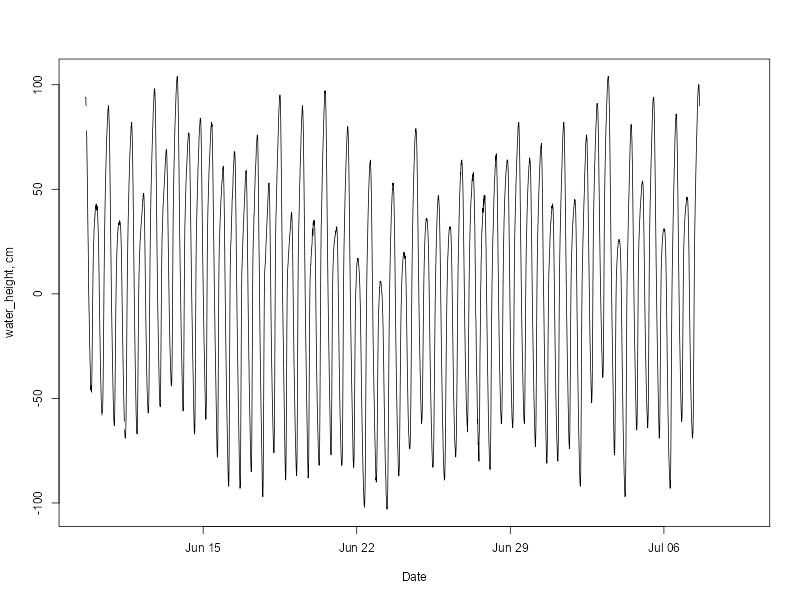

In [8]:
water_level_oudeschid <- read.csv("~/../../home/lter_life_dev/git_repos/vl-tempsed-wadden-sea/datasets/Waterhoogte in Oppervlaktewater texel.oudeschild.csv", sep = ";")[, 1:4]
names(water_level_oudeschid) <- c("date", "time", "location", "water_height")
head(water_level_oudeschid)

water_level_oudeschid$datetime <- as.POSIXct(paste(water_level_oudeschid$date, water_level_oudeschid$time), format = "%d-%m-%Y %H:%M")

plot(water_level_oudeschid$datetime, water_level_oudeschid$water_height, type = "l", ylab = "water_height, cm", xlab = "Date")


Similarly, we download temperature data from the same basis section as a separate file. Note that the station where Rijkwaterstraat deployed temperature is different from the water height, so you need to think hard about the implication of assuming that the temperature at the site of water height (Oudeschild) is similar to Marsdiep (nearest station)

![Landing page RWS](images/rws_screenshot_4.png)

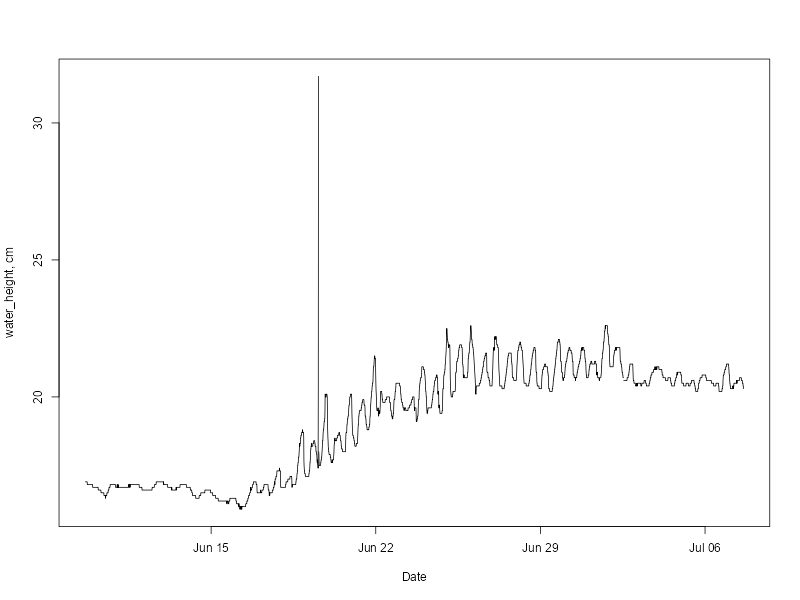

In [9]:
water_temperature_marsdiep <- read.csv("datasets/Watertemperatuur in oC denhelder.marsdiep.csv", sep = ";")

names(water_temperature_marsdiep) <- c("date", "time", "location", "water_temperature")

water_temperature_marsdiep$water_temperature <- gsub(",", ".", water_temperature_marsdiep$water_temperature)

water_temperature_marsdiep$water_temperature <- as.numeric(water_temperature_marsdiep$water_temperature)
head(water_temperature_marsdiep)


water_temperature_marsdiep$datetime <- as.POSIXct(paste(water_temperature_marsdiep$date, water_temperature_marsdiep$time), format = "%d-%m-%Y %H:%M")

plot(water_temperature_marsdiep$datetime, water_temperature_marsdiep$water_temperature, type = "l", ylab = "water_height, cm", xlab = "Date")

With this, you can build your `forcing function` of the water for this recent data (useful in your case) that drive *heat* exchange with the sediment. 

In [18]:
fTwater <- water_temperature_marsdiep
fTwater$second <- as.numeric(difftime(fTwater$datetime, start_date, units = "secs"))
fTwater <- fTwater[, c("second", "water_temperature")]

fHwater <- water_level_oudeschid
fHwater$second <- as.numeric(difftime(fHwater$datetime, start_date, units = "secs"))
fHwater <- fHwater[, c("second", "water_height")]

This is what you will most likely use for the your case in this MaMa course. Adapt the code accordingly or come ask me if you run into any issue. 

### Model Runs

For how long do we run this model for? Given the different temporal resolution of the data we are using to force the model (meterological data, water guage, water temperature sensor etc) we can use some quick routine to calculate the minimum and maximum range for which our model run encompasses the available forcing data. 

In [8]:
### Load your data 
(time_wizard <- find_time_comparison_function(list(fwind = fWind_wad, frad = fRad_wad, ftair = fTair_wad, fpair = fPair_wad, 
                                   fhum = fhumidity_wad, 
                                   fcloud = fCloud_wad, fhwater = fHwater, ftwater = fTwater )))

$LatestStartFunction
[1] "fwind"

$FirstSecond
[1] 0

$EarliestEndFunction
[1] "fhwater"

$LastSecond
[1] 31532400


So, the result says we run the model from time `r time_wizard$FirstSecond` to `r time_wizard$LastSecond` second.


Now, you are ready to run the model using the data you have downloaded. Atmospheric forcing...check! Boundary conditions...check! What about parameters? In the sediment, there are lot of things going on. There are sediment being deposited and eroded periodically so the net effect is sediment is compacted, some worms and crabs are moving around and doing their wormy/crabby thing etc. All these effect need to **parameterized**. Depending on your background, we can go in-depth or simple. Here, we will start simple and depending on how good your model fit we can add some realism.

For a start, we can model sediment compaction using porosity. Given our site, we need to know what type of sediment were are observing. Is it sandy, muddy, or something in between. This is important as it affect the porosity of the sediment layer. Think about that when you get your data from the lab for bulk density and grain size. For now we define porosity is a declining function from 0.9 near the SWI till 0.45 at depth.

In [9]:
# function describing the variation of porosity (volume fraction of LIQUID) with depth
porosity_fun  <- function(x, por.SWI = 0.9, por.deep = 0.7, porcoef = 100){
  return( por.deep + (por.SWI-por.deep)*exp(-x*porcoef) )
}



Next, I provide a suite of parameters that you can affect an intertidal mudflat sediment heat dynamics over a day. Don't worry if there are a lot. Some are pretty insignificant and other are not. You will explore how sensitive they are in the last section.


In [10]:
# parameters
parms <- list(em_air = 0.8, # [-] emissivity of air
              em_sediment = 0.95 * 1, # [-] emissivity of sediment
              stanton = 0.001 * 1, # [-] transfer coeff for sensible heat
              dalton = 0.0014 * 1, # [-] transfer coeff for latent heat
              density_water = 1024, # [kg/m3] seawater density
              density_solid = 2500, # [kg/m3] sediment dry density
              cp_water = 3994, # [J/kg/dgC] specific heat capacity water
              cp_solid = 700, # [J/kg/dgC] specific heat capacity solid (dry sediment)*
              tc_water = 0.6, # [W/m/dg] thermal conductivity of water
              tc_solid = 7, # [W/m/dg] thermal conductivity of solid* #1.68-19.21
              albedo_water = 0.05, # [-] part light reflected by water
              # albedo_sed = 0.1, # [-] part light reflected by sediment
              kd_water = 1, # [/m] light attenuation coefficient water (1-25/m in RT13)
              kd_sediment = 1000 # [/m] light attenuation coefficient (bulk) sediment
)

In [11]:

times <- seq(from = time_wizard$FirstSecond, to = time_wizard$LastSecond, by = 3600)

Tout_init <- TempSED_run1D(parms = parms, 
                      T_ini = 20, 
                      Grid = setup.grid.1D(N = 100, dx.1 = dz_1, L = length.z), 
                      times = times,
                      porosity = porosity_fun, 
                      dependency_on_T = FALSE,
                      f_Pressure = fPair_wad,
                      f_Airtemperature = fTair_wad, 
                      f_Waterheight = fHwater,
                      f_Watertemp = fTwater_int,
                      f_Qrel  = fhumidity_wad,
                      f_Solarradiation = fRad_wad, 
                      f_Windspeed = fWind_wad,
                      f_Cloudiness = fCloud_wad, 
                      sedpos = c(0, 0.01, 0.04))


Tout <- TempSED_run1D(parms = parms, 
                      T_ini = Tout_init, 
                      Grid = setup.grid.1D(N = 100, dx.1 = dz_1, L = length.z), 
                      times = times,
                      porosity = porosity_fun, 
                      dependency_on_T = FALSE,
                      f_Pressure = fPair_wad,
                      f_Airtemperature = fTair_wad, 
                      f_Waterheight = fHwater,
                      f_Watertemp = fTwater_int,
                      f_Qrel  = fhumidity_wad,
                      f_Solarradiation = fRad_wad, 
                      f_Windspeed = fWind_wad,
                      f_Cloudiness = fCloud_wad, 
                      sedpos = c(0, 0.01, 0.04))


### Model validation

Now we can validate how the model perform. We are going to plot the observed data from the field to the model and hopefully we can start to tweak things.

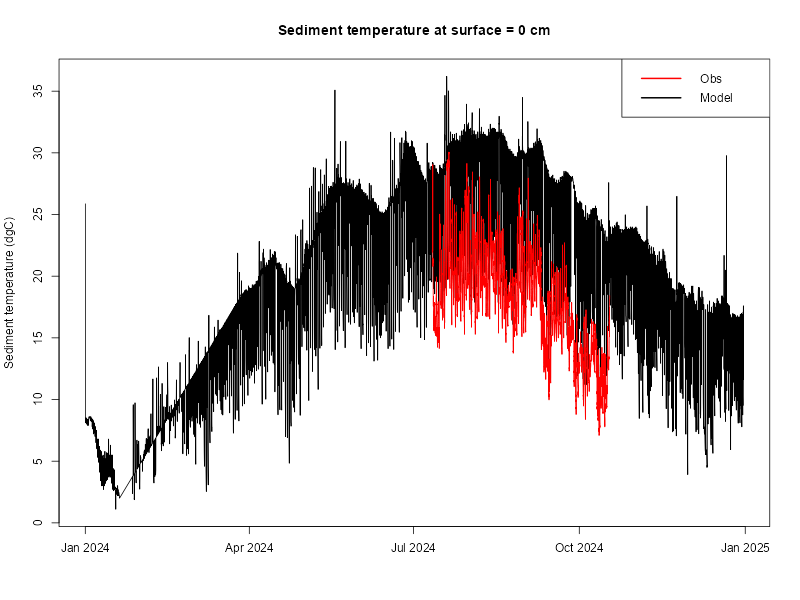

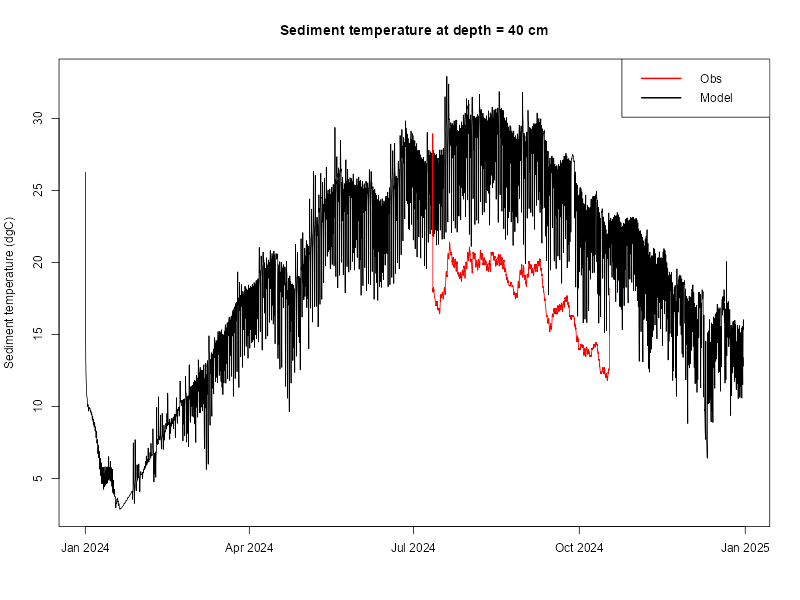

In [12]:
model_time <- as.POSIXct(Tout[, "time"], origin = "2024-01-01 00:00:00") 
model_temp <- subset(Tout, which = "Tsed_0") 
plot(model_time, model_temp, type = "l", 
     xlab = "", ylab = "Sediment temperature (dgC)", 
     main = "Sediment temperature at surface = 0 cm")
lines(data_21923817$date, data_21923817$temperature, col = "red", lwd = 1)
legend("topright", legend = c("Obs", "Model"), col = c("red", "black"), lwd = 2)


## Deep sediment 
model_time <- as.POSIXct(Tout[, "time"], origin = "2024-01-01 00:00:00") 
model_temp <- subset(Tout, which = "Tsed_0.04") 
plot(model_time, model_temp, type = "l", 
     xlab = "", ylab = "Sediment temperature (dgC)", 
     main = "Sediment temperature at depth = 40 cm")
lines(data_22026091$date, data_22026091$temperature, col = "red", lwd = 1)
legend("topright", legend = c("Obs", "Model"), col = c("red", "black"), lwd = 2)



Of course, this is not perfect. In the surface we are slightly off compared to the data but in the deep we are way off. So we need to calibrate the model with physical basis in the next step. You can play with some parameters to test how sensitive the model fit relative to the data is. 

### Sensitivity experiments

To test how sensitive the model is to a particular parameter, you can `perturb` that parameter called $x$ by a given value $\delta x$, the change in the model state variable $y$ relative to the normal state is then calculated. If the relative change of variable to the *perturb parameter* is large, we can say the parameter is very sensitive. Doing this across a sensible range of physical/ecological relevant parameters we can adjust our model fit relative to the data, calculate the impact of changes in the parameters/forcing and perhaps imagine future scenario when external forcings (these are technically parameters in model) changes along with the influence on the sediment heat budget. 

For example, remember our porosity function, we can modify it to test how sensitive surface porosity is to modifying the simulated sediment temperature. Let decrease it by 0.1 unit (i.e surface porosity = 0.8)

In [ ]:
new_porosity_fun  <- function(x, por.SWI = 0.8, por.deep = 0.45, porcoef = 50){
  return( por.deep + (por.SWI-por.deep)*exp(-x*porcoef) )
}

Now we run the model again and plot the data in comparison to previous result

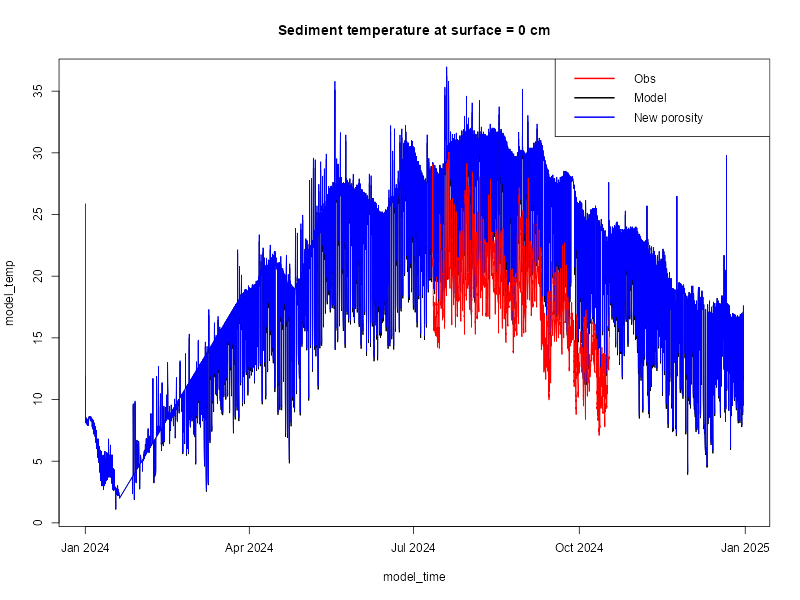

In [ ]:
Tout_init <- TempSED_run1D(parms = parms, 
                      T_ini = 20, 
                      Grid = setup.grid.1D(N = 100, dx.1 = dz_1, L = length.z), 
                      times = times, 
                      porosity = porosity_fun(setup.grid.1D(N = 100, dx.1 = dz_1, L = length.z)$x.int, por.SWI = 0.8),
                      dependency_on_T = FALSE,
                      f_Pressure = fPair_wad,
                      f_Airtemperature = fTair_wad, 
                      f_Waterheight = fHwater,
                      f_Watertemp = fTwater_int,
                      f_Qrel  = fhumidity_wad,
                      f_Solarradiation = fRad_wad, 
                      f_Windspeed = fWind_wad,
                      f_Cloudiness = fCloud_wad, 
                      sedpos = c(0, 0.01, 0.04))


Tout_new_porosity <- TempSED_run1D(parms = parms, 
                      T_ini = Tout_init, 
                      Grid = setup.grid.1D(N = 100, dx.1 = dz_1, L = length.z), 
                      times = times,
                      porosity = porosity_fun(setup.grid.1D(N = 100, dx.1 = dz_1, L = length.z)$x.int, por.SWI = 0.8),
                      dependency_on_T = FALSE,
                      f_Pressure = fPair_wad,
                      f_Airtemperature = fTair_wad, 
                      f_Waterheight = fHwater,
                      f_Watertemp = fTwater_int,
                      f_Qrel  = fhumidity_wad,
                      f_Solarradiation = fRad_wad, 
                      f_Windspeed = fWind_wad,
                      f_Cloudiness = fCloud_wad, 
                      sedpos = c(0, 0.01, 0.04))


model_time <- as.POSIXct(Tout[, "time"], origin = "2024-01-01 00:00:00") 
model_temp <- subset(Tout, which = "Tsed_0") 
plot(model_time, model_temp, type = "l", col = "black",
     main = "Sediment temperature at surface = 0 cm")

model_time <- as.POSIXct(Tout_new_porosity[, "time"], origin = "2024-01-01 00:00:00") 
new_por_model_temp <- subset(Tout_new_porosity, which = "Tsed_0") 
lines(model_time, new_por_model_temp, col = "blue")

lines(data_21923817$date, data_21923817$temperature, col = "red", lwd = 1)
legend("topright", legend = c("Obs", "Model", "New porosity"), col = c("red", "black", "blue"), lwd = 2)





It looks like nothing change, the blue (with new surface porosity of 0.8) is overlapping the black line (old surface porosity of 0.9). However, if we zoom in a little of the plot, we see show changes:

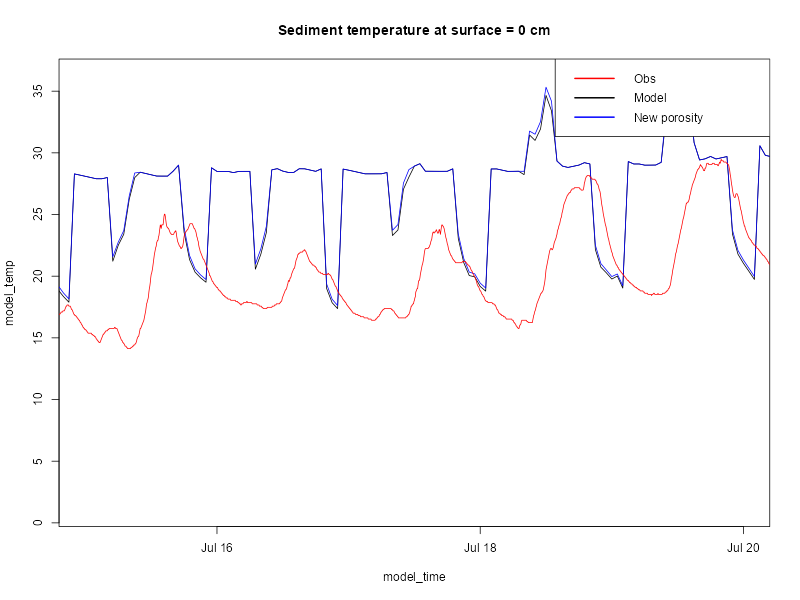

In [26]:
model_time <- as.POSIXct(Tout[, "time"], origin = "2024-01-01 00:00:00") 
model_temp <- subset(Tout, which = "Tsed_0") 
plot(model_time, model_temp, type = "l", col = "black", xlim = as.POSIXct(c("2024-07-15", "2024-07-20")),
     main = "Sediment temperature at surface = 0 cm")

model_time <- as.POSIXct(Tout_new_porosity[, "time"], origin = "2024-01-01 00:00:00") 
new_por_model_temp <- subset(Tout_new_porosity, which = "Tsed_0") 
lines(model_time, new_por_model_temp, col = "blue")

lines(data_21923817$date, data_21923817$temperature, col = "red", lwd = 1)
legend("topright", legend = c("Obs", "Model", "New porosity"), col = c("red", "black", "blue"), lwd = 2)

This shows that surface porosity of 0.8 matter little in the modifying the sediment temperature. Thinking of its, a porosity of 0.9 or 0.8 means we are still in muddy terrain so they are essentially the same. However, in sandy sediment we can have porosity of about 30 to 40%. Depending on the bulk density, grain size and other parameters, you can modify the coefficient in the model to reconstruct your observation. This is where science happen. The hard part!



### Miscellaneous things 
If you have a working model, you can visualize the depth profile of the sediment over time as we did earlier. 

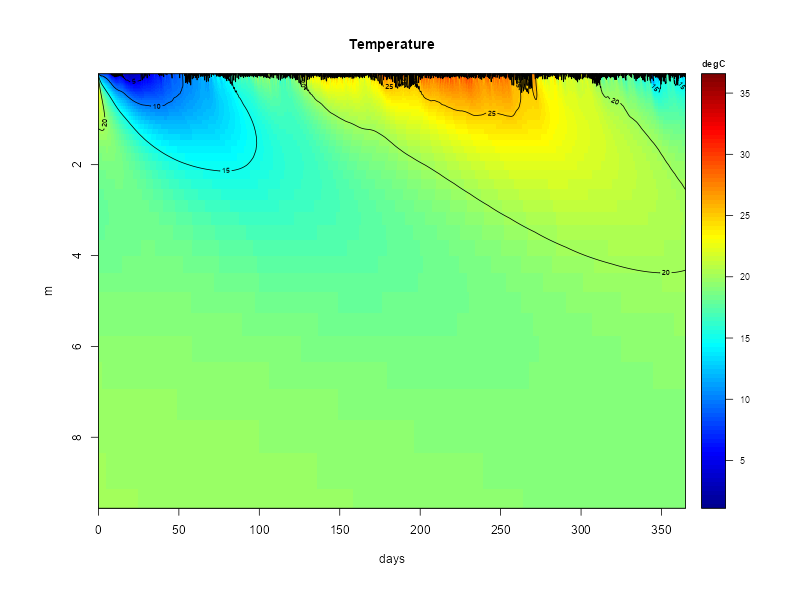

Warning message:
In rep(dots, length.out = n) : 'x' is NULL so the result will be NULL


In [28]:
image2D(Tout, main = "Temperature", xlab = "days",
        clab = "degC", ylab = "m", time_unit = "day",
        contour = TRUE, mfrow = NULL)



With this, we can start to bring our thinking on the ecological implication of the sediment temperature distribution. What depth does our lugworms penetrate in and what is the corresponding temperature at the depth? In a future scenario, temperature changes, how will our fauna adapt? etc

You can also compute the integrated heat budget over the period of interest


In [27]:
TempSED_budget(Tout, how = "integral", remove_ini = TRUE)

  Heat_accumulation      Heatflux_total       Heatflux_deep Heatflux_convection  Heatflux_radiation 
      -1.306534e+07       -2.596327e+08        0.000000e+00       -5.051377e+08        2.501527e+09 
    Heatflux_latent   Heatflux_sensible    Heatflux_backrad           precision 
      -1.287045e+09       -3.294308e+08       -6.395464e+08       -1.887187e+03 
attr(,"title")
[1] "integrated heat fluxes over time interval"
attr(,"description")
                 names         units                                                              description
1    Heat_accumulation J/m2, [1 sec]                                                   Heat added to sediment
11      Heatflux_total J/m2, [1 sec]                              Total heat added (upper boundary+radiation)
12 Heatflux_convection J/m2, [1 sec]                               Convective heat flux with overlying water 
13  Heatflux_radiation J/m2, [1 sec]                                           Shortwave radiation heat input
14

Lastly, if you are bold enough we can think of ways to couple the sediment temperature to the thermal tolerance of benthic organisms. Each organism will have a temperature threshold for which live becomes unbearable. We can encode that in our model, using the output of the physical model (temperature) on a biological response function. I will leave that as a teaser for you. If interested, ask me and I can show a simple version. 

Good luck with your field data &#x270A;